In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Network Edges
from itertools import combinations
import networkx as nx
from collections import Counter

#TF-IDF matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
df.shape

(8807, 12)

In [5]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

**Filling the missing dates.**

In [6]:
# Fill null values in 'date_added' with 'January 01, year' from 'release_year'
df.loc[df['date_added'].isnull(), 'date_added'] = df[df['date_added'].isnull()]['release_year'].apply(lambda x: f'January 01, {x}')

# Convert 'date_added' column to datetime objects, using 'mixed' format to handle inconsistencies
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')

In [7]:
df['duration_in_mins'] = df['duration'].apply(
    lambda x: int(x.split()[0]) if isinstance(x, str) and 'min' in x else np.nan
)

**Netflix Content Distribution.**

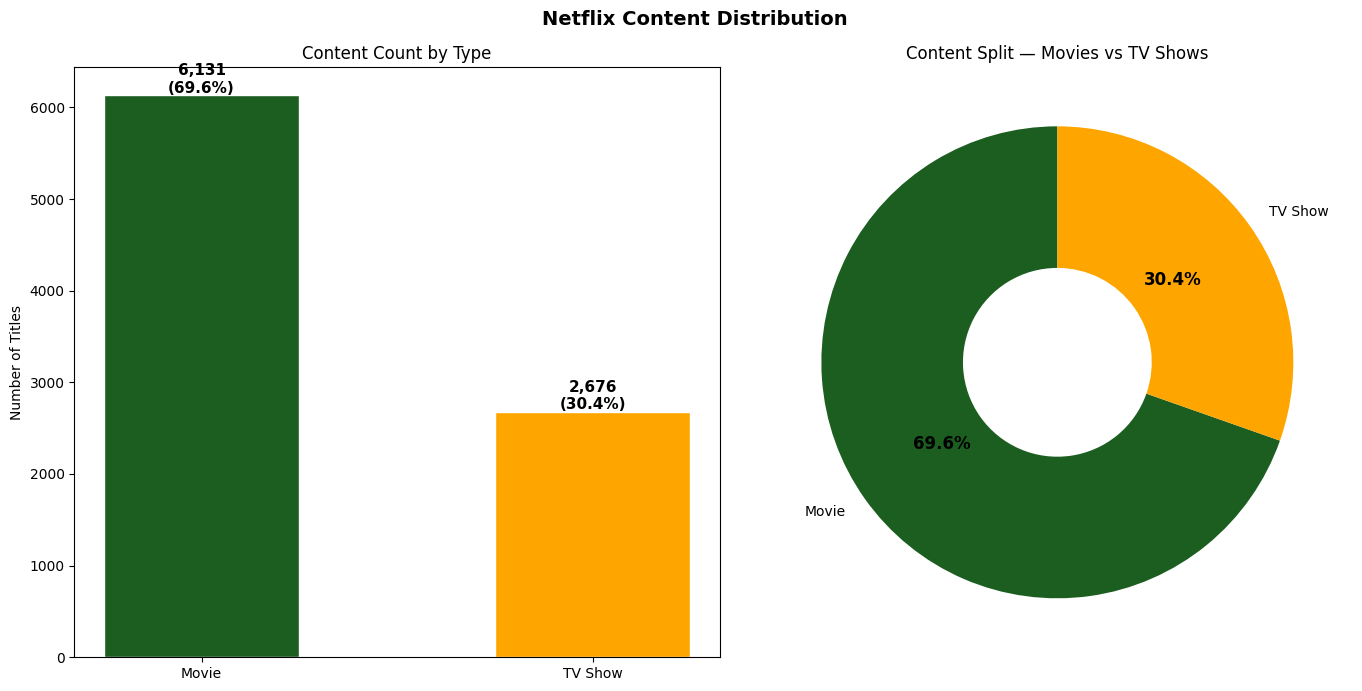

There are 6,131 movies (69.6%)
There are : 2,676 TV Shows  (30.4%)
Netflix has significantly more Movies than TV Shows in its catalog.


In [8]:
type_counts = df['type'].value_counts()
type_pct    = (type_counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Bar chart
bars = axes[0].bar(type_counts.index, type_counts.values, color = ['#1b5e20', '#FFA500'],
                  edgecolor='white', width=0.5)
axes[0].set_title('Content Count by Type')
axes[0].set_ylabel('Number of Titles')
for bar, val, pct in zip(bars, type_counts.values, type_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({pct}%)', ha='center', fontsize=11, fontweight='bold')

# Donut chart
wedges, texts, autotexts = axes[1].pie(
    type_counts.values,
    labels=type_counts.index,
    colors = ['#1b5e20', '#FFA500'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.6)
)
for text in autotexts:
    text.set_fontsize(12)
    text.set_fontweight('bold')
axes[1].set_title('Content Split — Movies vs TV Shows')

fig.suptitle('Netflix Content Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'There are {type_counts["Movie"]:,} movies ({type_pct["Movie"]}%)')
print(f'There are : {type_counts["TV Show"]:,} TV Shows  ({type_pct["TV Show"]}%)')
print('Netflix has significantly more Movies than TV Shows in its catalog.')

**Content type distribution.**

In [9]:
movies_dur = df[(df['type'] == 'Movie') & (df['duration_in_mins'].notna())]
movies_dur = movies_dur[(movies_dur['duration_in_mins'] > 30) & (movies_dur['duration_in_mins'] < 250)]


shows_dur = df[(df['type'] == 'TV Show') & (df['duration'].notna())].copy()
# Extract numeric seasons
shows_dur['season_num'] = shows_dur['duration'].str.split().str[0].astype(int)

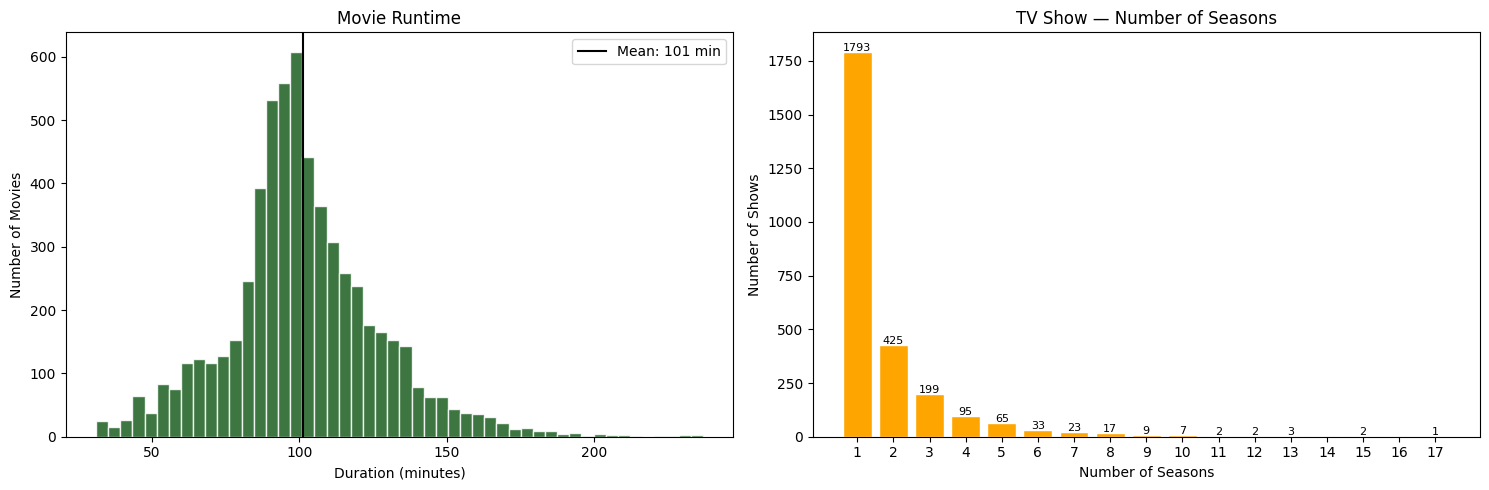

The Average movie runtime is 101 minutes.
There are  1,793 (67.0%) TV Shows with only 1 season.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Movies distribution.
axes[0].hist(movies_dur['duration_in_mins'], bins=50, color='#1b5e20', edgecolor='white', alpha=0.85)

# Mean line
axes[0].axvline(movies_dur['duration_in_mins'].mean(), color='black', linestyle='-',
                linewidth=1.5, label=f'Mean: {movies_dur["duration_in_mins"].mean():.0f} min')

axes[0].set_title('Movie Runtime')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Number of Movies')
axes[0].legend()

# TV Shows distribution

season_counts = shows_dur['season_num'].value_counts().sort_index().head(15)

axes[1].set_xticks(range(1, int(season_counts.index.max()) + 1))
axes[1].bar(season_counts.index, season_counts.values,
            color='#FFA500', edgecolor='white')

axes[1].set_title('TV Show — Number of Seasons')
axes[1].set_xlabel('Number of Seasons')
axes[1].set_ylabel('Number of Shows')

#Labels on bars
for x, y in zip(season_counts.index, season_counts.values):
    axes[1].text(x, y + 5, str(y), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f'The Average movie runtime is {movies_dur["duration_in_mins"].mean():.0f} minutes.')

one_season = (shows_dur['season_num'] == 1).sum()

print(f'There are  {one_season:,} ({one_season/len(shows_dur)*100:.1f}%) TV Shows with only 1 season.')

**Checking inconsistencies in the durations.**

In [11]:
df[(df['type'] == 'Movie') & (df['duration_in_mins'].isna())]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_in_mins
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi...",NaN
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...,NaN
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...,NaN


In [12]:
mask = df['duration'].isna() & df['rating'].str.contains('min|Season', na=False)
df.loc[mask, 'duration'] = df.loc[mask, 'rating']

In [13]:
df.loc[mask, 'rating'] = np.nan

In [14]:
df.iloc[5541]

show_id                                                         s5542
type                                                            Movie
title                                                 Louis C.K. 2017
director                                                   Louis C.K.
cast                                                       Louis C.K.
country                                                 United States
date_added                                        2017-04-04 00:00:00
release_year                                                     2017
rating                                                            NaN
duration                                                       74 min
listed_in                                                      Movies
description         Louis C.K. muses on religion, eternal love, gi...
duration_in_mins                                                  NaN
Name: 5541, dtype: object

**Ratings Categorisation.**

In [15]:
df['rating'].value_counts(dropna = False)

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
NaN            7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [16]:
def category_rating(rating):
  if rating in ['TV-Y', 'TV-Y7', 'TV-Y7-FV', 'TV-G', 'G']:
    return 'Kids'
  elif rating in ['TV-PG', 'PG', 'PG-13']:
    return 'Family/PG'
  elif rating in ['TV-14']:
    return 'Teens'
  elif rating in ['R', 'NC-17', 'TV-MA']:
    return 'Adult'
  else:
    return 'Unknown'

df['rating_category'] = df['rating'].apply(category_rating)


print("Content ratings were grouped into Kids, Family/PG, Teens, Adult, and Unknown to simplify analysis and better")
print("understand overall distribution patterns.")

Content ratings were grouped into Kids, Family/PG, Teens, Adult, and Unknown to simplify analysis and better
understand overall distribution patterns.


In [17]:
cat_count = df['rating_category'].value_counts().reset_index()
cat_count

,rating_category,count
0,Adult,4009
1,Teens,2160
2,Family/PG,1640
3,Kids,908
4,Unknown,90


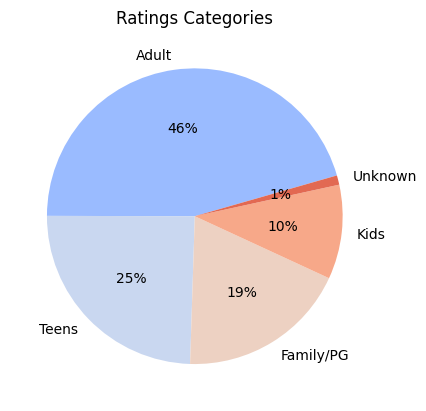

Titles categorised as Adult: 4,009 45.5%
Netflix’s catalog has a higher proportion of adult-oriented content (~46%), making it the largest category
among all rating groups.


In [18]:
plt.pie(cat_count['count'], labels = cat_count['rating_category'], 
        colors = sns.color_palette('coolwarm')[1:7], startangle = 16, autopct='%.0f%%')
plt.title('Ratings Categories')
plt.show()

adult_count = cat_count.loc[cat_count['rating_category'] == 'Adult', 'count'].values[0]
total = cat_count['count'].sum()

adult_perc = adult_count / total * 100

print(f"Titles categorised as Adult: {adult_count:,} {adult_perc:.1f}%")
print("Netflix’s catalog has a higher proportion of adult-oriented content (~46%), making it the largest category") 
print("among all rating groups.")

**Content Distribution by Countries.**

In [19]:
df['country'].value_counts(dropna = False)

country
United States                                             2818
India                                                      972
NaN                                                        831
United Kingdom                                             419
Japan                                                      245
                                                          ... 
Germany, Canada, United States                               1
Denmark, United Kingdom, South Africa, Sweden, Belgium       1
Serbia, South Korea, Slovenia                                1
United Kingdom, Spain, Belgium                               1
South Africa, United States, Japan                           1
Name: count, Length: 749, dtype: int64

In [20]:
df['country'] = df['country'].str.split(', ')
df_exploded = df.explode('country')

In [21]:
country_count = df_exploded['country'].value_counts(dropna = False).head(11).reset_index()
country_count

,country,count
0,United States,3689
1,India,1046
2,NaN,831
3,United Kingdom,804
4,Canada,445
5,France,393
6,Japan,318
7,Spain,232
8,South Korea,231
9,Germany,226


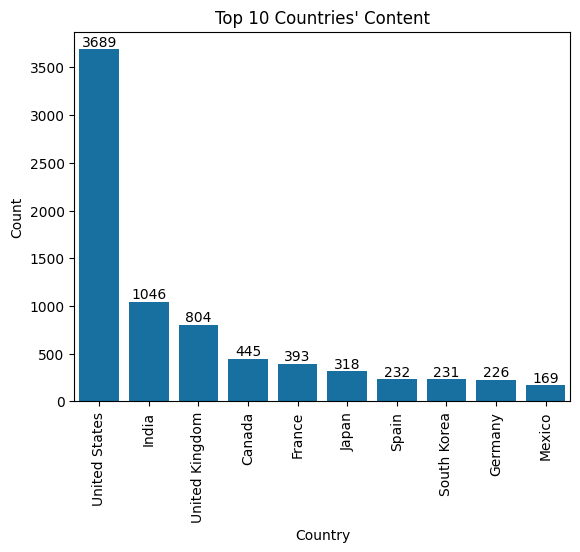

The United States accounts for approximately 34.0% of the total Netflix content (including entries
with missing country data).
The top 3 countries together contribute about 55.3% of the total content, while the top 5 countries
account for nearly 63.7%, both calculated after excluding entries with missing country information.


In [22]:
ax = sns.barplot(x='country', y='count', color='#0077b6', data=country_count)
plt.title('Top 10 Countries\' Content')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation = 90)

ax.bar_label(ax.containers[0], fontsize=10);

plt.show()


country_full = df_exploded['country'].value_counts(dropna=False)
total_full = country_full.sum()

usa_count = country_full.get('United States', 0)
usa_perc = usa_count / total_full * 100

country_no_nan = df_exploded['country'].dropna().value_counts()
total_no_nan = country_no_nan.sum()

#top 3
top3 = country_no_nan.head(3)
top3_perc = top3.sum() / total_no_nan * 100

#top 5
top5 = country_no_nan.head(5)
top5_perc = top5.sum() / total_no_nan * 100

print(f"The United States accounts for approximately {usa_perc:.1f}% of the total Netflix content (including entries") 
print("with missing country data).")
print(f"The top 3 countries together contribute about {top3_perc:.1f}% of the total content, while the top 5 countries") 
print(f"account for nearly {top5_perc:.1f}%, both calculated after excluding entries with missing country information.")

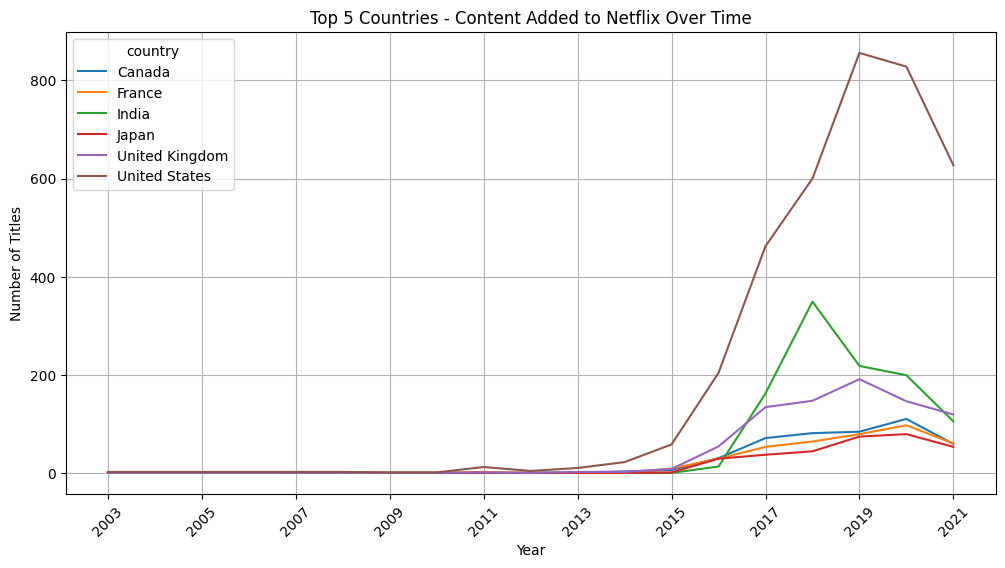

Entries with missing country information were included in the analysis due to their significant count.


In [23]:
# Ensure datetime + year
df_exploded['date_added'] = pd.to_datetime(df_exploded['date_added'])
df_exploded['year_added'] = df_exploded['date_added'].dt.year

# Get top 5 countries
top_5 = df_exploded['country'].value_counts().head(6).index

# Filter + group
trend = (
    df_exploded[df_exploded['country'].isin(top_5)]
    .groupby(['year_added', 'country'])
    .size()
    .unstack()
    .fillna(0)
    .sort_index()
)

# Clean + filter years
trend = trend.sort_index().fillna(0)

# Plot

trend.plot(figsize=(12, 6))

plt.title('Top 5 Countries - Content Added to Netflix Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.xticks(range(trend.index.min(), trend.index.max()+1, 2), rotation=45)


# Set x-axis ticks from beginning in increments of 2
min_year_trend = trend.index.get_level_values('year_added').min()
max_year_trend = trend.index.get_level_values('year_added').max()
plt.xticks(range(min_year_trend, max_year_trend + 1, 2), rotation=45)

plt.show()

print("Entries with missing country information were included in the analysis due to their significant count.")

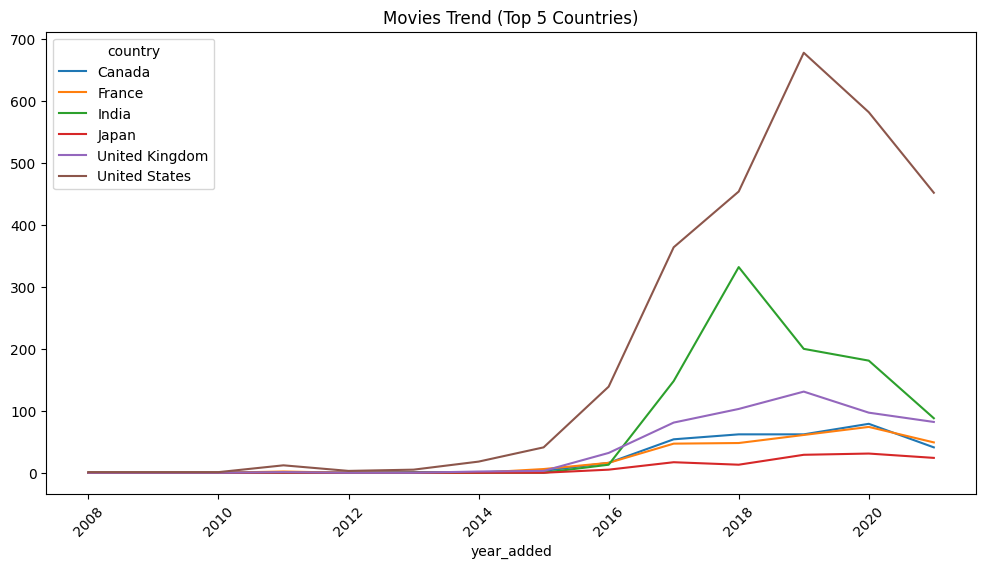

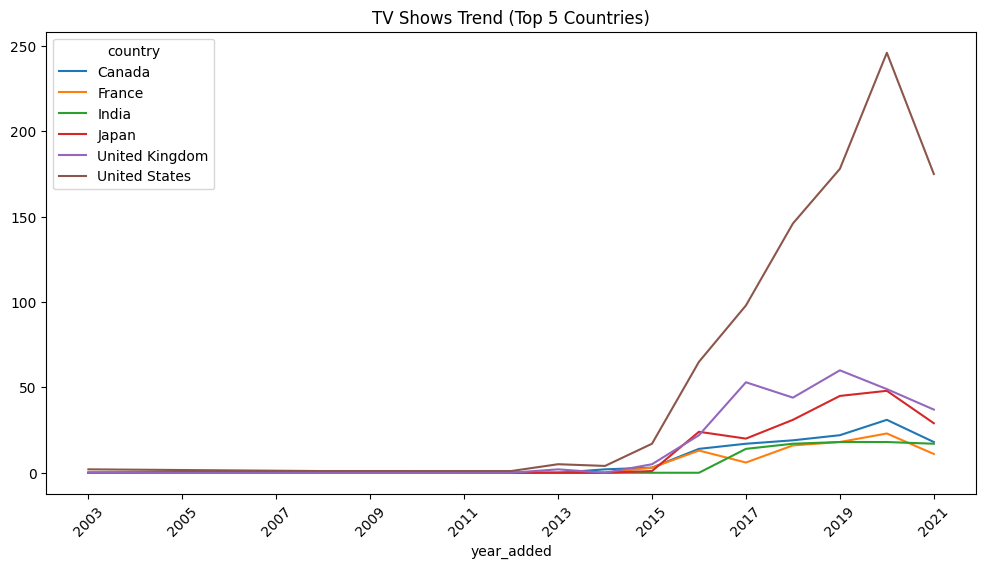

Content additions for both Movies and TV Shows increased significantly between 2016 and 2019,
followed by a noticeable decline in later years.


In [24]:
top_5 = df_exploded['country'].value_counts().head(6).index
df_top5 = df_exploded[df_exploded['country'].isin(top_5)]

movies_trend = df_top5[df_top5['type'] == 'Movie'] \
    .groupby(['year_added', 'country']).size().unstack().sort_index().fillna(0)

tv_trend = df_top5[df_top5['type'] == 'TV Show'] \
    .groupby(['year_added', 'country']).size().unstack().sort_index().fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))

movies_trend.plot(ax=ax, title='Movies Trend (Top 5 Countries)')

years = movies_trend.index
ax.set_xticks(range(int(years.min()), int(years.max()) + 1, 2))

plt.xticks(rotation=45)
plt.show()


fig, ax = plt.subplots(figsize=(12, 6))

tv_trend.plot(ax=ax, title='TV Shows Trend (Top 5 Countries)')

years = tv_trend.index
ax.set_xticks(range(int(years.min()), int(years.max()) + 1, 2))

plt.xticks(rotation=45)
plt.show()

print("Content additions for both Movies and TV Shows increased significantly between 2016 and 2019,") 
print("followed by a noticeable decline in later years.")

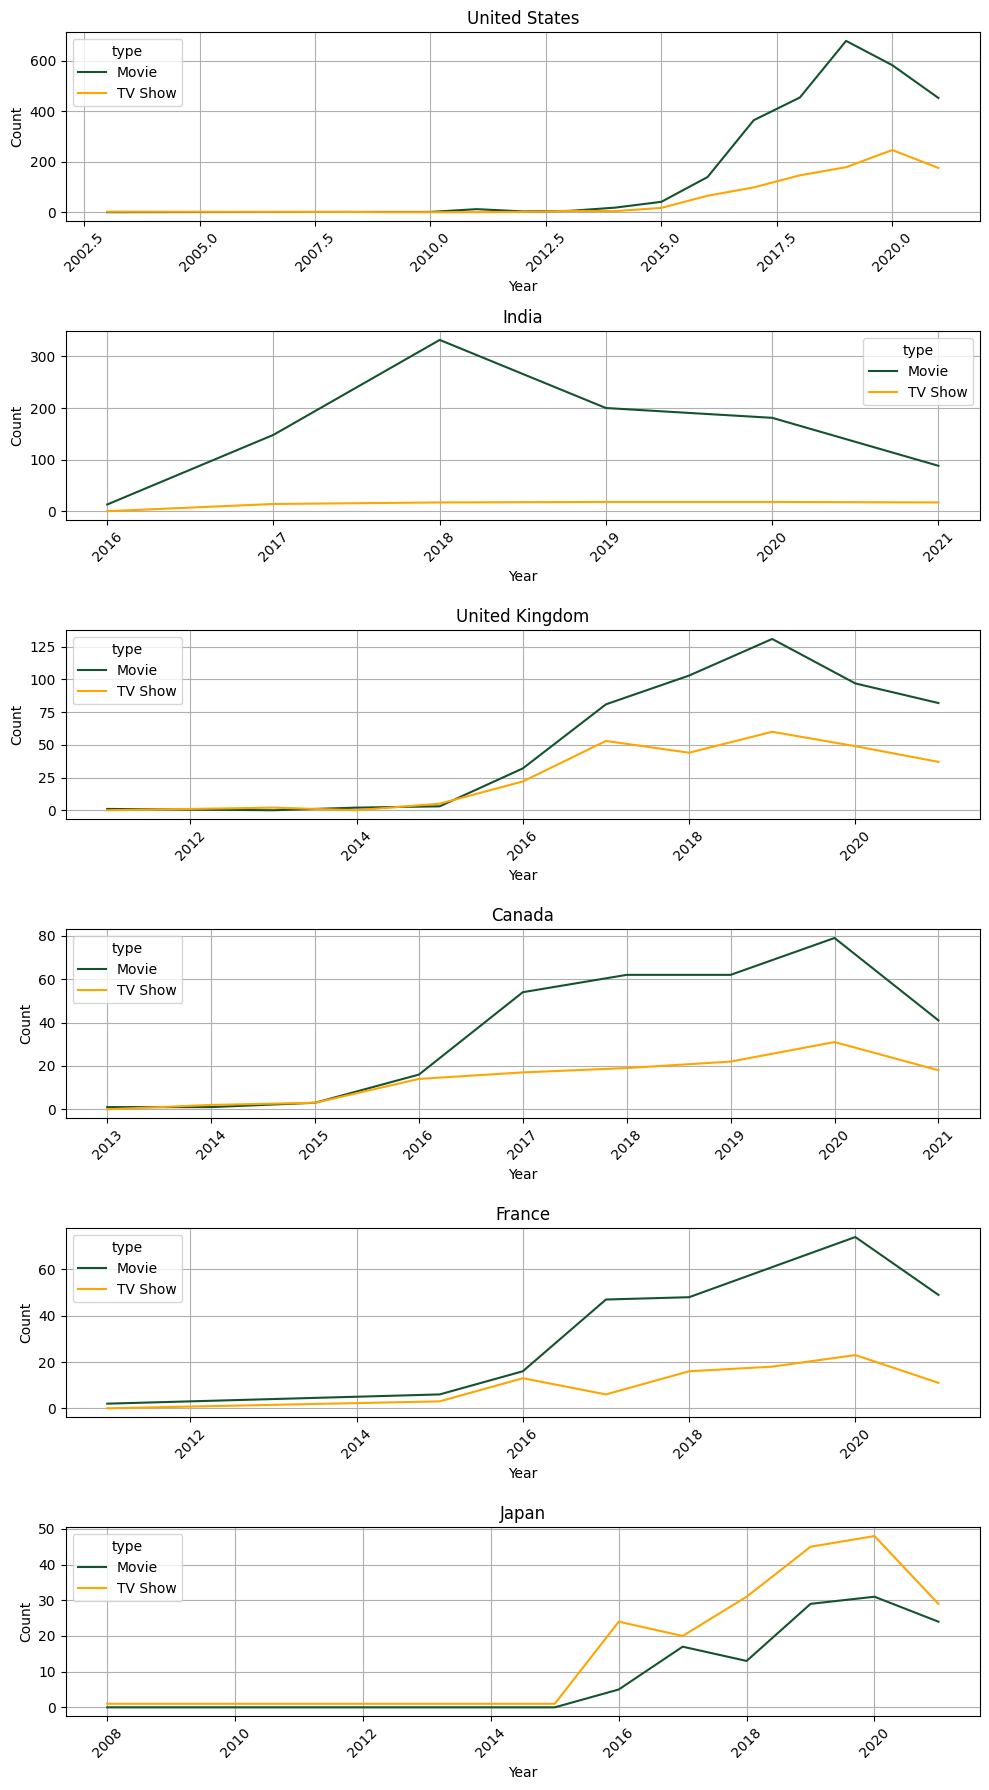

Netflix initially had a strong focus on the United States, which continues to be the dominant contributor
to its content library.
Over time, the platform expanded globally, with a significant surge in content additions observed
between 2015 and 2019, aligning with its international expansion phase.

In recent years, countries like India have started contributing more significantly to the platform’s catalog,
indicating growing regional participation.
However, the number of titles added shows a slight decline post-2019, suggesting a shift in content addition trends.


In [25]:
# Create trend with type included
trend = (
    df_exploded[df_exploded['country'].isin(top_5)]
    .groupby(['year_added', 'country', 'type'])
    .size()
    .unstack()
    .fillna(0)
    .sort_index()
)

colors = ['#14532d', '#FFA500']
# Create subplots
fig, axes = plt.subplots(6, 1, figsize=(10, 18))

for i, country in enumerate(top_5):
    data = trend.xs(country, level='country')

    data.plot(ax=axes[i], color=colors)

    axes[i].set_title(country)
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Count')
    axes[i].grid(True)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Netflix initially had a strong focus on the United States, which continues to be the dominant contributor")
print("to its content library.") 
print("Over time, the platform expanded globally, with a significant surge in content additions observed") 
print("between 2015 and 2019, aligning with its international expansion phase.\n")

print("In recent years, countries like India have started contributing more significantly to the platform’s catalog,")
print("indicating growing regional participation.") 
print("However, the number of titles added shows a slight decline post-2019, suggesting a shift in content addition trends.")

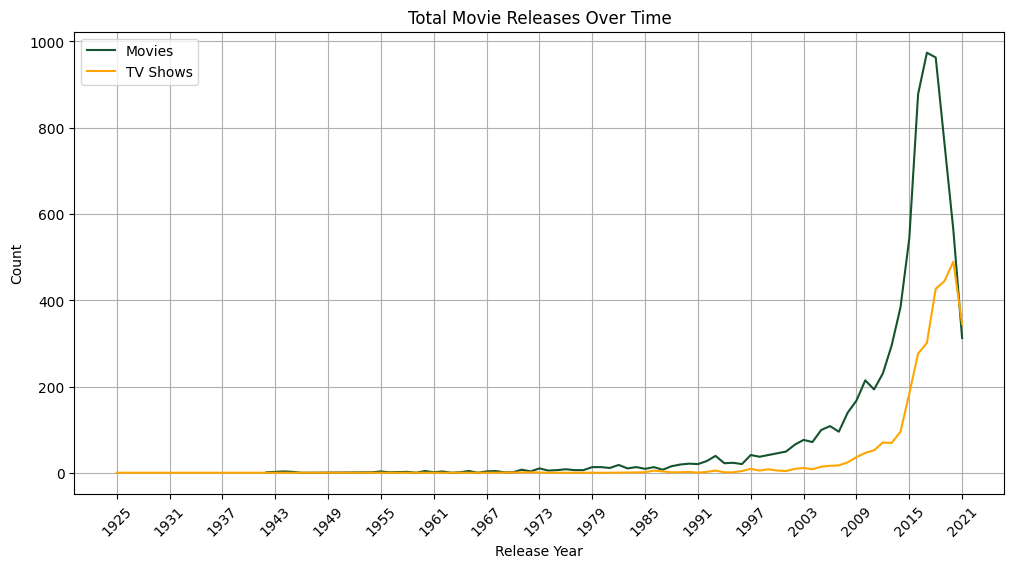

In [26]:
movies = df_exploded[df_exploded['type'] == 'Movie']
series = df_exploded[df_exploded['type'] == 'TV Show']

movies_per_year = movies['release_year'].value_counts().reset_index()
series_per_year = series['release_year'].value_counts().reset_index()

plt.figure(figsize=(12, 6))

sns.lineplot(
    x='release_year',
    y='count',
    data=movies_per_year,
    label='Movies',
    color='#14532d'   
)

sns.lineplot(
    x='release_year',
    y='count',
    data=series_per_year,
    label='TV Shows',
    color='#FFA500'   
)

plt.title('Total Movie Releases Over Time')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.grid(True)
plt.legend()

# Set x-axis intervals to 6 years
min_year = min(movies_per_year['release_year'].min(), series_per_year['release_year'].min())
max_year = max(movies_per_year['release_year'].max(), series_per_year['release_year'].max())
plt.xticks(range(min_year, max_year + 1, 6), rotation=45)

plt.show()

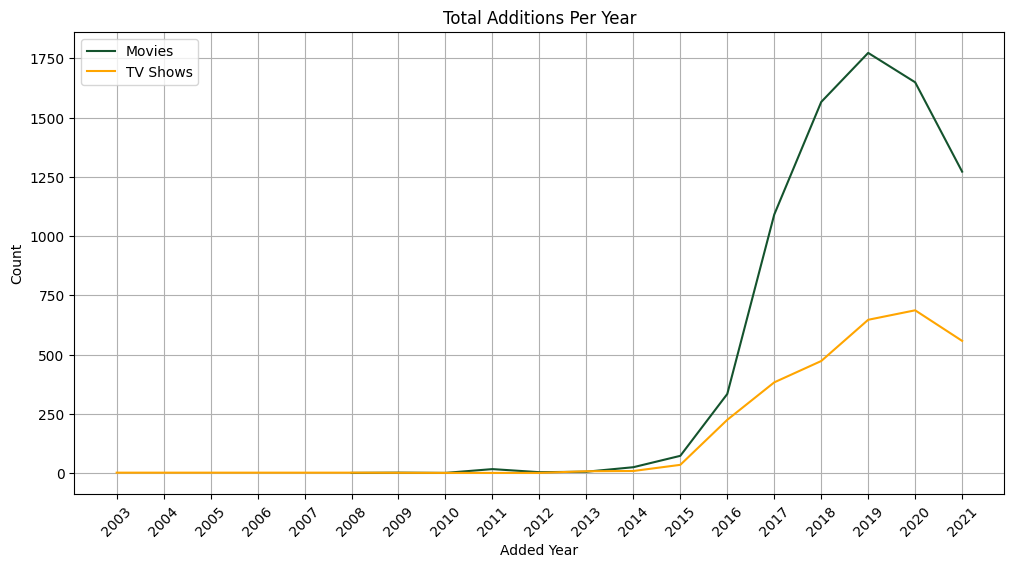

In [27]:
movies['date_added'] = pd.to_datetime(movies['date_added'])
movies['year_added'] = movies['date_added'].dt.year
movies_added_to_netflix = movies['year_added'].value_counts().reset_index()

series['date_added'] = pd.to_datetime(series['date_added'])
series['year_added'] = series['date_added'].dt.year
series_added_to_netflix = series['year_added'].value_counts().reset_index()



plt.figure(figsize=(12, 6))
sns.lineplot(x = 'year_added', y = 'count', data = movies_added_to_netflix, color='#14532d', label='Movies')
sns.lineplot(x = 'year_added', y = 'count', data = series_added_to_netflix, color='#FFA500', label='TV Shows')

plt.title('Total Additions Per Year')
plt.xlabel('Added Year')
plt.ylabel('Count')
plt.grid(True)
plt.legend()

# Set x-axis intervals to 1 year
min_year = min(movies_added_to_netflix['year_added'].min(), series_added_to_netflix['year_added'].min())
max_year = max(movies_added_to_netflix['year_added'].max(), series_added_to_netflix['year_added'].max())
plt.xticks(range(min_year, max_year + 1, 1), rotation=45)

plt.show()

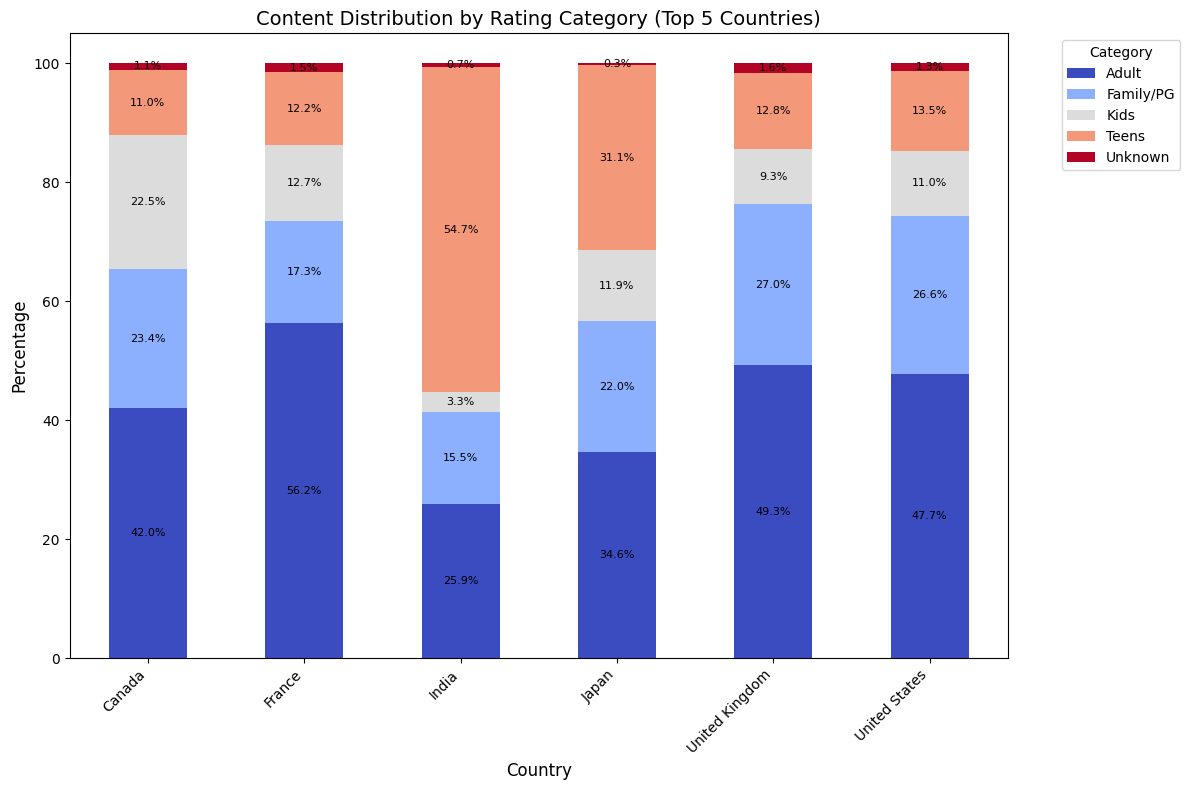

Most countries have a higher proportion of adult-oriented content, with France leading at over 55% of its titles.
The United Kingdom, United States, and Canada follow, each with more than 40% of their content in the adult category,
while India has the lowest share, with roughly one-fourth of its titles classified as adult.

In contrast, Indian content is predominantly teen-oriented, accounting for over 54% of its catalog.
Meanwhile, the United States, United Kingdom, and Canada maintain a more balanced distribution, with approximately
a quarter of their content suitable for family viewing.

Kids content remains relatively limited across most countries, averaging around 10%.
However, France stands out with a higher share (~22%), whereas India has a notably smaller proportion (~3%).


In [28]:
df_top5 = df_exploded[df_exploded['country'].isin(top_5)]

dist = (
    df_top5.groupby(['country', 'rating_category'])
    .size()
    .unstack()
    .fillna(0)
)

dist_pct = dist.div(dist.sum(axis=1), axis=0) * 100



ax = dist_pct.plot(kind='bar', stacked=True, figsize=(12, 8), cmap='coolwarm')

plt.title('Content Distribution by Rating Category (Top 5 Countries)', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Position the legend outside the plot
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add percentage values inside the bars
for container in ax.containers:
    labels = [f'{w:.1f}%' if (w := v.get_height()) > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=8, color='black')

plt.tight_layout()
plt.show()

print("Most countries have a higher proportion of adult-oriented content, with France leading at over 55% of its titles.") 
print("The United Kingdom, United States, and Canada follow, each with more than 40% of their content in the adult category,")
print("while India has the lowest share, with roughly one-fourth of its titles classified as adult.\n")

print("In contrast, Indian content is predominantly teen-oriented, accounting for over 54% of its catalog.") 
print("Meanwhile, the United States, United Kingdom, and Canada maintain a more balanced distribution, with approximately") 
print("a quarter of their content suitable for family viewing.\n")

print("Kids content remains relatively limited across most countries, averaging around 10%.")
print("However, France stands out with a higher share (~22%), whereas India has a notably smaller proportion (~3%).")

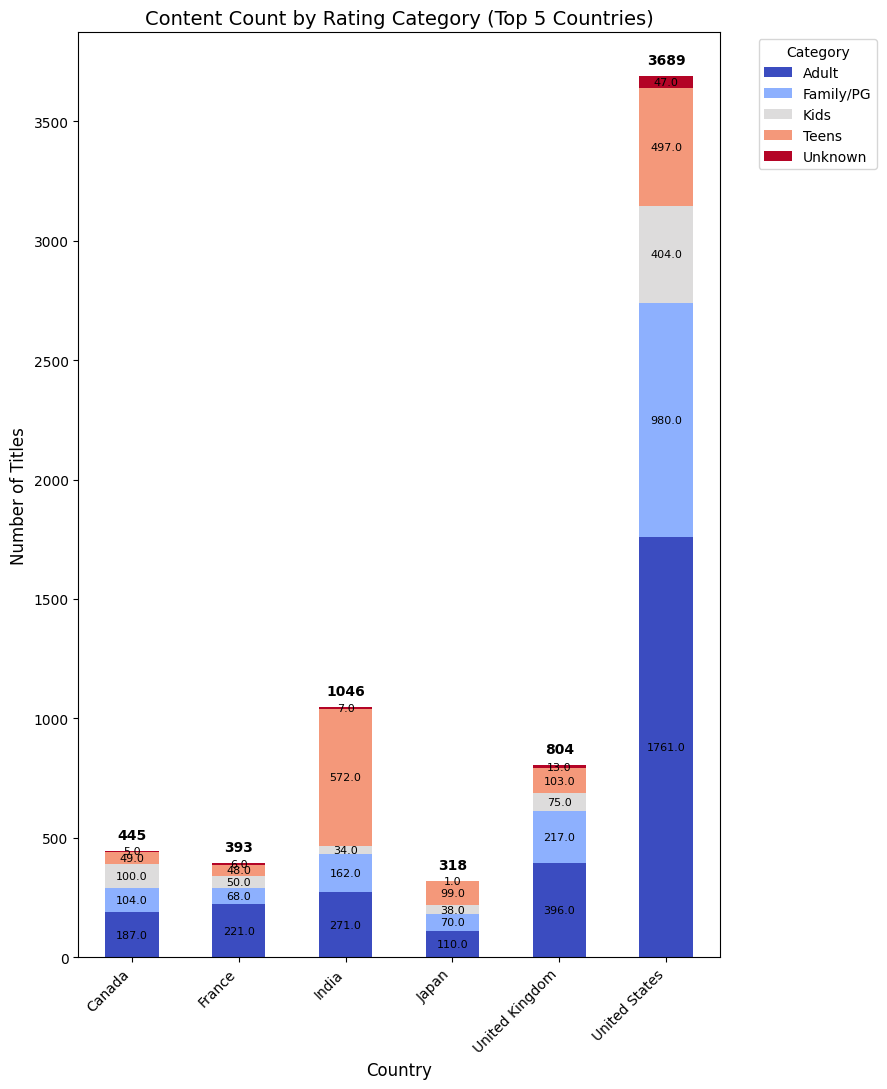

In [29]:
ax = dist.plot(kind='bar', stacked=True, figsize=(9, 11), cmap='coolwarm')

plt.title('Content Count by Rating Category (Top 5 Countries)', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add count labels
for container in ax.containers:
    labels = [f'{w:.1f}' if (w := v.get_height()) > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=8)

totals = dist.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(i, total + 50, str(int(total)), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Checking if any countries have more TV shows than the Movies.**

In [30]:
country_type = (
    df_exploded.groupby(['country', 'type'])
    .size()
    .unstack()
    .fillna(0)
)

In [31]:
tv_dominant = country_type[country_type['TV Show'] > country_type['Movie']]

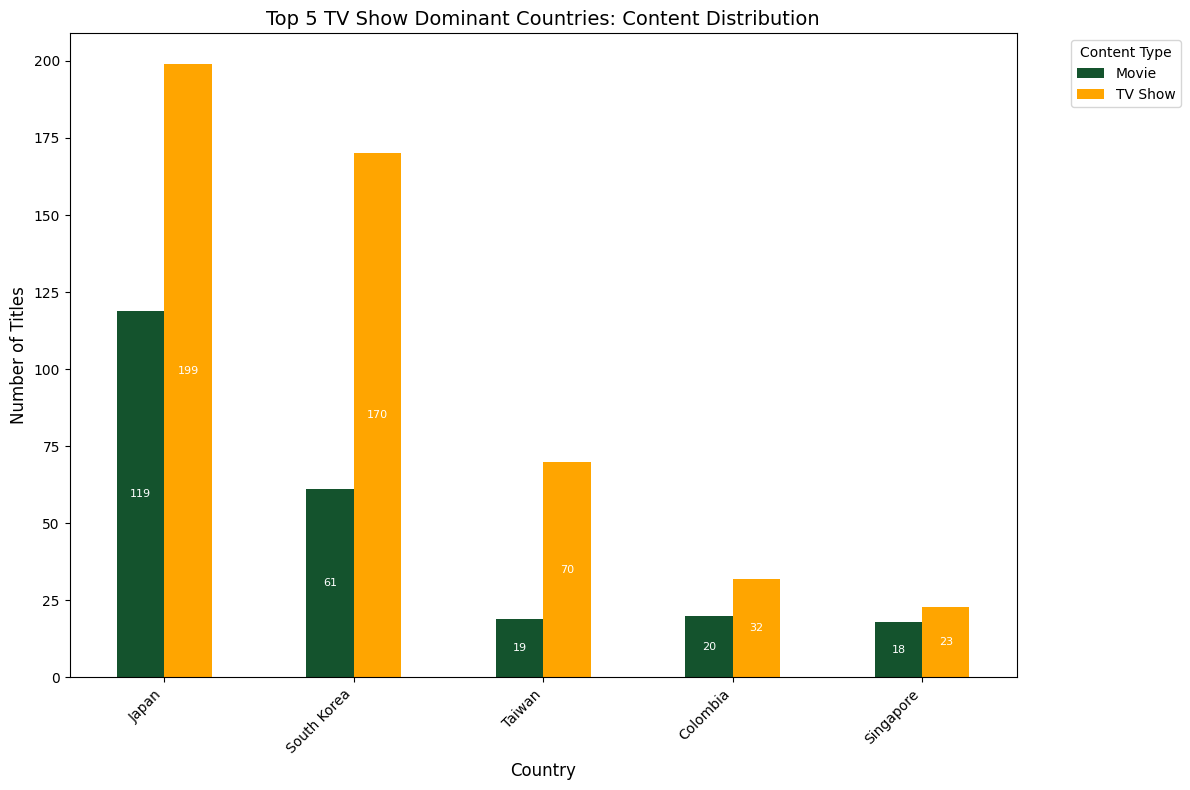

Japan, South Korea and Taiwan have gained popularity and success with their series rather than movies.


In [32]:
# Sort tv_dominant by 'TV Show' count and get the top 5
top_5_tv_dominant = tv_dominant.sort_values(by='TV Show', ascending=False).head(5)

# Plotting the side-by-side bar chart
ax = top_5_tv_dominant.plot(kind='bar', stacked=False, figsize=(12, 8), color=['#14532d', '#FFA500'])

plt.title('Top 5 TV Show Dominant Countries: Content Distribution', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.legend(title='Content Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add count labels inside the bars
for container in ax.containers:
    labels = [f'{int(v.get_height())}' if v.get_height() > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=8, color='white')

plt.tight_layout()
plt.show()

print("Japan, South Korea and Taiwan have gained popularity and success with their series rather than movies.")

**Director/Cast Analyses.**

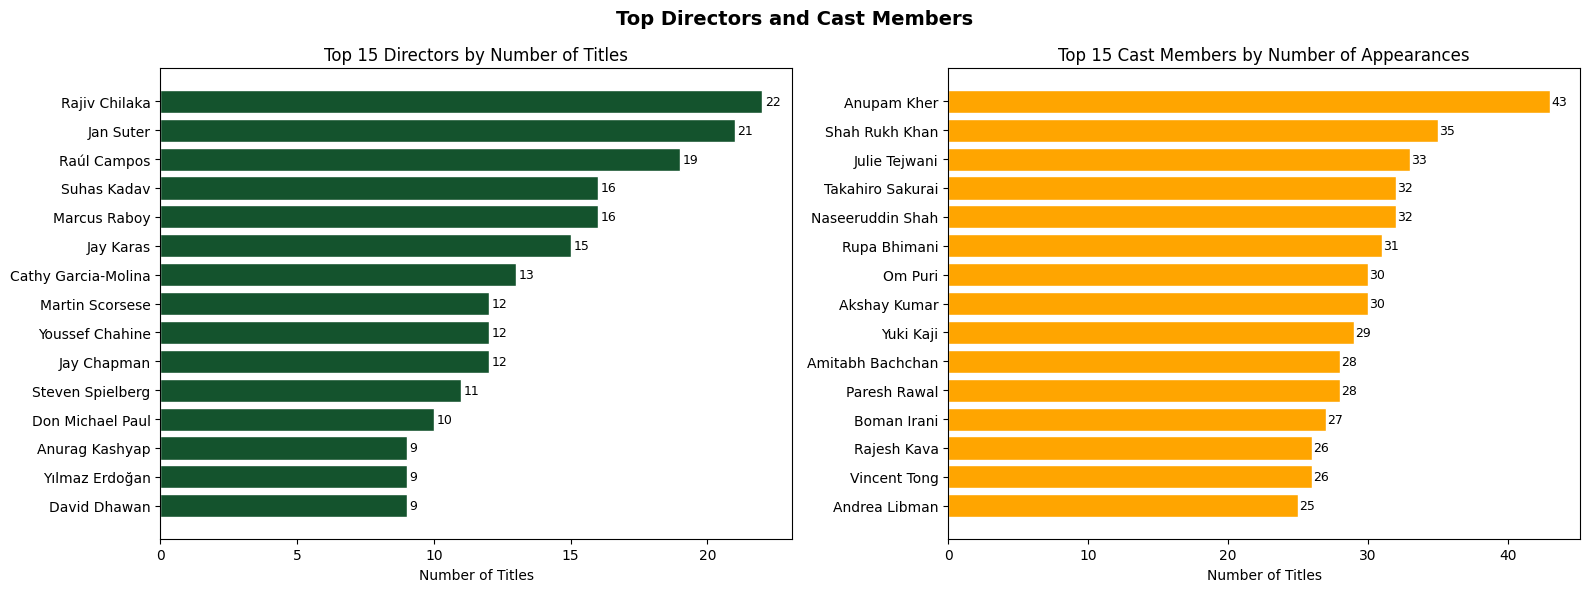

In [33]:
# Top Directors
directors = df['director'].dropna().str.split(', ').explode()
top_directors = directors.value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_directors.index[::-1], top_directors.values[::-1],
             color='#14532d', edgecolor='white')
axes[0].set_title('Top 15 Directors by Number of Titles')
axes[0].set_xlabel('Number of Titles')
for bar, val in zip(axes[0].patches, top_directors.values[::-1]):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)

# Top Cast Members
cast_members = df['cast'].dropna().str.split(', ').explode()
top_cast = cast_members.value_counts().head(15)

axes[1].barh(top_cast.index[::-1], top_cast.values[::-1],
             color='#FFA500', edgecolor='white')
axes[1].set_title('Top 15 Cast Members by Number of Appearances')
axes[1].set_xlabel('Number of Titles')
for bar, val in zip(axes[1].patches, top_cast.values[::-1]):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)

fig.suptitle('Top Directors and Cast Members', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Identifying similar content by matching text-based features.**

In [34]:
# Apply weights

df['combined'] = (
    (df['rating_category'].fillna('').str.strip() + ' ') * 3 +
    (df['listed_in'].fillna('').str.replace(',', ' ').str.strip() + ' ') * 2 +
    (df['cast'].fillna('').str.replace(',', ' ').str.strip() + ' ') +
    (df['country'].fillna('').str.replace(',', ' ').str.strip() + ' ') +
    df['description'].fillna('').str.strip()
).str.lower()

# Remove extra spaces (important cleanup)
df['combined'] = df['combined'].str.replace(r'\s+', ' ', regex=True).str.strip()

df['combined'] = df['combined'].fillna('').astype(str)

In [35]:
# tf-idf matrix. Converts text into numbers.
#In simple terms, it gives importance score to each word. Common words- low importance and rare/specific words- high importance.

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['combined'])

In [36]:
# build search function

def search_content(query, n=5):
    query_vec = tfidf.transform([query])
    scores = cosine_similarity(query_vec, tfidf_matrix).flatten()

    top_indices = scores.argsort()[-n:][::-1]

    return df[['title', 'listed_in', 'rating_category']].iloc[top_indices]

In [37]:
search_content("romance comedy")

,title,listed_in,rating_category
475,The Stand-Up,Stand-Up Comedy,Adult
2261,Jim Jefferies: Intolerant,Stand-Up Comedy,Adult
484,Lee Su-geun: The Sense Coach,Stand-Up Comedy,Kids
388,Plastic Cup Boyz: Laughing My Mask Off!,"Stand-Up Comedy & Talk Shows, TV Comedies",Adult
5790,The Best of Rafał Rutkowski Olka Szczęśniak,Stand-Up Comedy,Adult


**Network Analysis of Actor/ Director.**

In [38]:
df['cast'] = df['cast'].fillna('')
df['cast_list'] = df['cast'].apply(lambda x: [i.strip() for i in x.split(',')])

In [39]:
# Creating Edges.
# Creates actor pairs who worked together, meaning these actors appeared in same title.

edges_actor = []

for cast in df['cast_list']:
    for pair in combinations(cast, 2):
        edges_actor.append(pair)

In [40]:
# Build Network
# Creates a network where nodes = actors, edges = co-acting

G_actor = nx.Graph()
G_actor.add_edges_from(edges_actor)

**Analysis**

In [41]:
# Most connected actor
# Actos who worked with the most number of different actors

degree = sorted(G_actor.degree, key=lambda x: x[1], reverse=True)
degree[:10]

[('Anupam Kher', 273),
 ('Samuel L. Jackson', 239),
 ('Takahiro Sakurai', 228),
 ('Fred Tatasciore', 226),
 ('Yuichi Nakamura', 223),
 ('Yuki Kaji', 220),
 ('Shah Rukh Khan', 210),
 ('Fred Armisen', 209),
 ('Akshay Kumar', 193),
 ('Katsuyuki Konishi', 191)]

In [42]:
edge_counts = Counter(edges_actor)
edge_counts.most_common(10)

[(('Julie Tejwani', 'Rupa Bhimani'), 24),
 (('Julie Tejwani', 'Rajesh Kava'), 23),
 (('Rupa Bhimani', 'Rajesh Kava'), 22),
 (('Julie Tejwani', 'Jigna Bhardwaj'), 20),
 (('Jigna Bhardwaj', 'Rajesh Kava'), 20),
 (('Rupa Bhimani', 'Jigna Bhardwaj'), 19),
 (('Vatsal Dubey', 'Julie Tejwani'), 18),
 (('Vatsal Dubey', 'Rupa Bhimani'), 18),
 (('Vatsal Dubey', 'Jigna Bhardwaj'), 18),
 (('Vatsal Dubey', 'Rajesh Kava'), 17)]

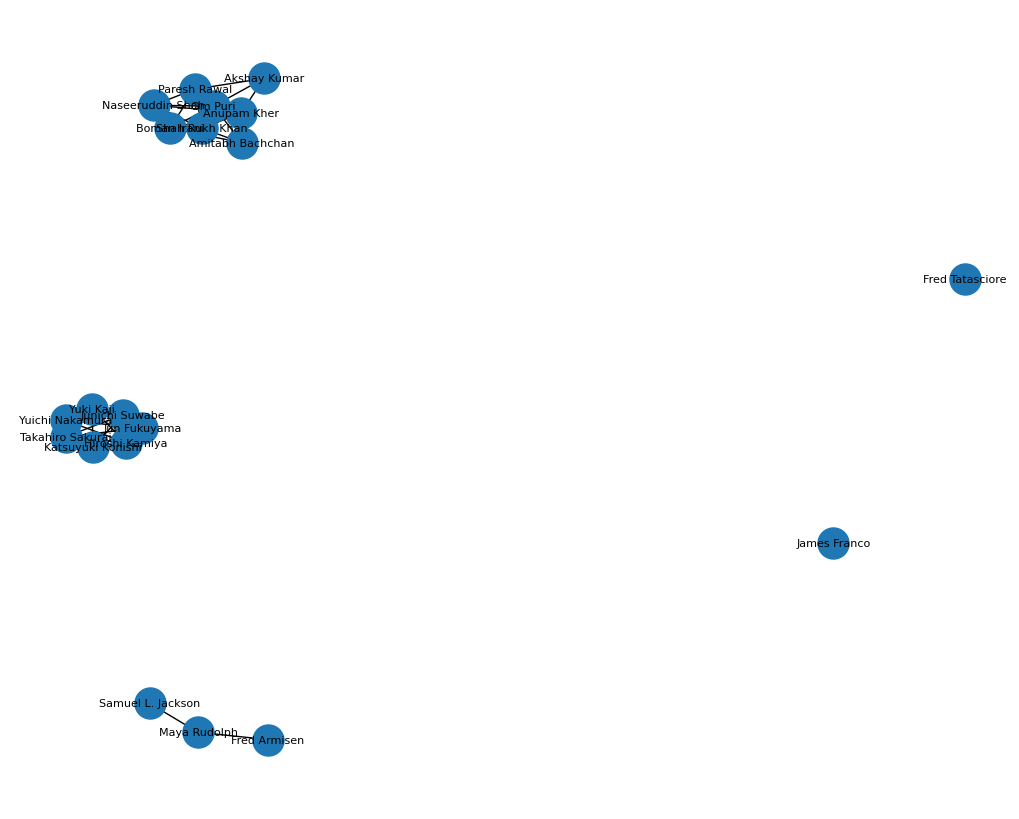

In [43]:
# Viz

top_nodes = [node for node, _ in degree[:20]]
subgraph = G_actor.subgraph(top_nodes)

pos = nx.spring_layout(subgraph, seed=42)

plt.figure(figsize=(10, 8))
nx.draw(subgraph, pos, with_labels=True, node_size=500, font_size=8)
plt.show()

**Director - Actor Network**

In [44]:
edges_director = []

df['cast'] = df['cast'].fillna('')
df['director'] = df['director'].fillna('')

#Build director-actor edges. Creates director-actor connections.
for _, row in df.iterrows():
    cast_list = [i.strip() for i in row['cast'].split(',') if i.strip()]
    director = row['director']

    # connect director to each actor
    for actor in cast_list:
        if director:  # avoid empty director
            edges_director.append((director, actor))

In [45]:
print(edges_director[:10])
len(edges_director)

[('Julien Leclercq', 'Sami Bouajila'), ('Julien Leclercq', 'Tracy Gotoas'), ('Julien Leclercq', 'Samuel Jouy'), ('Julien Leclercq', 'Nabiha Akkari'), ('Julien Leclercq', 'Sofia Lesaffre'), ('Julien Leclercq', 'Salim Kechiouche'), ('Julien Leclercq', 'Noureddine Farihi'), ('Julien Leclercq', 'Geert Van Rampelberg'), ('Julien Leclercq', 'Bakary Diombera'), ('Mike Flanagan', 'Kate Siegel')]


45465

In [46]:
# Total actors + directors in network

unique_nodes = set([node for edge in edges_director for node in edge])
len(unique_nodes)

30496

In [47]:
edges_df = pd.DataFrame(edges_director, columns=['director', 'actor'])
edges_df.head()

,director,actor
0,Julien Leclercq,Sami Bouajila
1,Julien Leclercq,Tracy Gotoas
2,Julien Leclercq,Samuel Jouy
3,Julien Leclercq,Nabiha Akkari
4,Julien Leclercq,Sofia Lesaffre


In [48]:
# Director–Actor pairs who worked together often

edges_df.value_counts().head(10)

director        actor             
Rajiv Chilaka   Rajesh Kava           17
                Jigna Bhardwaj        17
                Julie Tejwani         17
                Rupa Bhimani          16
                Vatsal Dubey          15
                Swapnil               12
                Mousam                12
Suhas Kadav     Saurav Chakraborty     8
S.S. Rajamouli  Prabhas                7
                Nassar                 7
Name: count, dtype: int64

In [49]:
# Nodes = actors + directors; Edges = worked together

G_director = nx.Graph()
G_director.add_edges_from(edges_director)

# number of nodes and edges
print("Nodes:", G_director.number_of_nodes())
print("Edges:", G_director.number_of_edges())

Nodes: 30496
Edges: 43087


In [50]:
# Most Connected People (includes actors and directors).

degree = sorted(G_director.degree, key=lambda x: x[1], reverse=True)
degree[:10]

[('Martin Scorsese', 121),
 ('Steven Spielberg', 116),
 ('Cathy Garcia-Molina', 90),
 ('Don Michael Paul', 79),
 ('Youssef Chahine', 76),
 ('Kunle Afolayan', 76),
 ('Robert Rodriguez', 74),
 ('Clint Eastwood', 72),
 ('Quentin Tarantino', 72),
 ('McG', 71)]

**Summary:**

1. Movies dominate Netflix’s catalog, accounting for more than two-thirds of the total content.
2. The average movie runtime is around 100 minutes, with most titles falling within a standard range and very few extreme short (<30 mins) or long (>240 mins) durations.
3. TV content is largely short-form, with about 67% of shows having only one season and nearly 90% having three seasons or fewer, indicating a strong presence of limited series.
4. Adult content forms the largest segment (~46%), suggesting Netflix primarily targets a mature audience while still maintaining variety.
5. The United States is the leading content contributor (~34%), highlighting its dominance in Netflix’s catalog.
6. Content additions peaked between 2015 and 2019, aligning with Netflix’s global expansion phase and aggressive content acquisition strategy.
7. Countries like Japan, South Korea, and Taiwan show stronger performance in TV series than movies, indicating regional preferences for episodic content.

**Conclusion.**

Netflix’s content strategy is driven by scale, global expansion, and engagement optimization. The platform relies heavily on movies to build a large and diverse catalog quickly, while leveraging shorter, limited-series TV content to maximize viewer engagement. Its library is predominantly adult-focused and heavily influenced by the United States, though regional markets such as Japan, South Korea, and Taiwan show a clear preference in TV series formats. The rapid increase in content between 2015 and 2019 reflects Netflix’s aggressive international expansion, where it prioritized quantity, localization, and binge-worthy formats to capture global audiences.